<a href="https://colab.research.google.com/github/Racim-dev/MACHINE-LEARNING/blob/main/ENPC_TP4_ML_STUDENTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP 4: Validation and Regularization**

------------------
Loic Landrieu 2024

------------------

In this exercise, we will explore  the key concepts in machine learning of validation and regularization. These techniques are crucial for building models that generalize well to unseen data.

We will start by generating synthetic data and visualizing it to understand the underlying patterns. Then, we will experiment with polynomial regression models of varying complexity and apply Ridge regularization to prevent overfitting.

By the end of this exercise, you should have a solid understanding of how to properly select model hyperparameters using a validation set and how regularization helps control model complexity.

For the report, provide a link to your code (do not forget to set access: three dots-> Share->Share then Share Acess -> Anyone with the link -> Viewer).
Also provide a PDF with an analysis and screenshots of figure **for Q9 and 9 ONLY**.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
SEED=41

In [ ]:
def RMSE(x,y):
  return np.sqrt(mean_squared_error(x,y))

## Q1) Data Generation

We first implement a function that represents the true underlying relation between the variable X (observation) and Y (targets) that we want to regress.

- `true_function(X)` takes as input observations X and returns Y.


- `generate_data(D, N, noise)` function creates synthetic data by generating random input values `X` and computing corresponding target values `Y` using the `true_function(X)`. Gaussian noise is added to the target values to simulate real-world data.


### Task:
- Complete the function `generate_data`.



In [ ]:
# Function to generate the target values based on a true underlying function
def true_function(X):
    """
    The function we want to regress.
    INPUTS:
    X : numpy.ndarray of size NxD
    RETURNS:
    Y : numpy.ndarray of size N
    """
    np.random.seed(SEED)  # Set the seed for reproducibility
    D = X.shape[1]

    # Generate random weights and shifts for each dimension
    weights = np.random.normal(loc=0, scale=1, size=D)
    shifts = np.random.normal(loc=0, scale=1, size=D)

    #some non linear function chosen arbirarily
    Y = np.sum([weights[i] * (np.sin(3 * np.pi * (X[:, i] + shifts[i])) +
        np.cos(2 * np.pi * X[:, i] - shifts[i])) for i in range(D)], axis=0)
    return Y

def generate_data(D=1, N=100, noise_level=0.1):
    """
    Generate synthetic noisy data for regression tasks.
    INPUTS:
    D : int, Number of dimensions of the input data
    N : int, Number of samples to generate.
    noise_level : float, Standard deviation of Gaussian noise

    RETURNS:
    tuple
        X : numpy.ndarray, input data of shape (N, D).
        Y : numpy.ndarray, target values with added noise.
    """
    X = np.random.rand(N, D)  # Generate random input data
    Y = true_function(X)  # Compute target values using the true function
    np.random.seed(SEED)  # Set the seed for reproducibility
    noise = noise_level * np.random.randn(N)  # Generate Gaussian noise
    Y += noise  # Add noise to the target values
    return X, Y

## Q2) Data Visualization

We want to visualize the relationship between the input variable `X` and the target variable `Y`.

### Task:
1. **Data Generation**:
   - Generate the synthetic data `X` and `Y` with `D=1` dimension and `N=100` samples using the `generate_data` function.
   
2. **Train-Test Split**:
   - Split into training and testing sets using sklearn's `train_test_split` to allocate 80% of the data for testing and the rest for training.
   
3. **Visualization**:
   - Plot the training data points using `plt.scatter`.
   - Plot the true function.


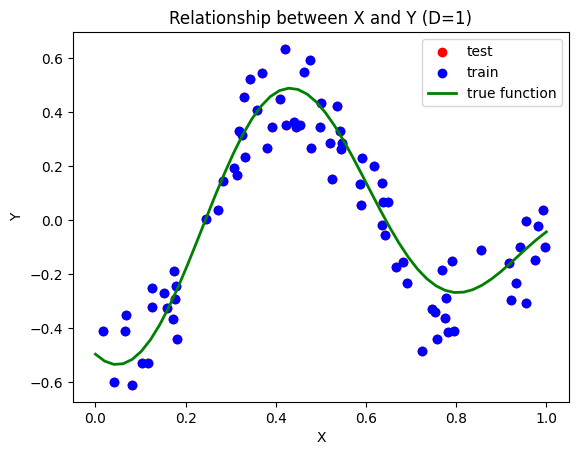

In [ ]:
# Generate synthetic data with 1 dimension and 100 samples
X, Y = generate_data()

# Split the data into training (20%) and test (80%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,  test_size=0.8, train_size=0.2)

# Plot the training data points
plt.scatter(X_test, Y_test, color='red', label='test')
plt.scatter(X_test, Y_test, color='blue', label='train') #TODO same for train, and in blue

# Plot the true function curve using the generated data points
data_points = np.linspace(0, 1, 50)[:, None]
plt.plot(data_points, true_function(data_points), color='green', linewidth=2, label='true function')  #TODO, color='green', linewidth=2, label='true function')

# Set plot labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Relationship between X and Y (D=1)')
plt.legend()
plt.show()

## Q3) Polynomial Regression

We will fit and apply a polynomial regression model to our data. Polynomial regression is a form of linear regression where the relationship between the independent variable `X` and the dependent variable `Y` is modeled as an nth degree polynomial.

### TASKS:
1. Complete `poly_fit(X, Y, degree)`: this function generates polynomial features from the input data `X` up to the specified degree and fits a linear regression model to the transformed data.
2. Complete `poly_apply(lin_reg, degree, X)`: this function applies a fitted polynomial regression model to new data `X`.

In [ ]:
def poly_fit(X, Y, deg, verbose=True):
    """
    Fits a polynomial regression model to the data.

    INPUTS:
    X : numpy.ndarray, Input data of shape (N, D)
    Y : numpy.ndarray, Target values of shape (N,).
    deg : int, degree of the polynomial features.
    verbose : bool, If True, prints the transformation details.

    RETURNS:
    LinearRegression, The fitted linear regression model.
    """
    # Generate polynomial features up to the specified degree
    X_poly = PolynomialFeatures(degree=deg).fit_transform(X)

    if verbose:
        print(f"From {X.shape[1]} dimension(s) to {X_poly.shape[1]} polynomial feature(s)")

    # Initialize and fit the linear regression model from X_poly to Y
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, Y)

    return lin_reg

# Function to apply the polynomial regression model to new data
def poly_apply(lin_reg, degree, X):
    """
    Applies the fitted polynomial regression model to new data.

    INPUTS:
    lin_reg : LinearRegression, The fitted linear regression model.
    degree : int, The degree of the polynomial features used in the model.
    X : numpy.ndarray, Input data to apply the model on, of shape (N, D).

    RETRUNS:
    numpy.ndarray, The predicted target values for the input data.
    """
    # Generate polynomial features for the new data
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X)

    # Predict target values using the fitted model
    return lin_reg.predict(X_poly)


## Q4) Model Evaluation and Overfitting

We evaluate the performance of polynomial regression models using different degrees of polynomials. Specifically, we will focus on understanding how the degree of the polynomial affects the model's performance on training and test data.

### TASKS:
1. **Model Fitting**: Fit a polynomial regression model with a degree `deg` to the training data using the `poly_fit` function.

2. **Performance Evaluation**: Calculate the Root Mean Squared Error (RMSE) for both the training and test sets.

3. **Visualization**: Plot the training and test data points along with the true function and the polynomial model's approximation.

4. **Analysis**: Try different values of `deg'.



From 1 dimension(s) to 6 polynomial feature(s)
Degree = 5, RMSE_train = 0.072, RMSE_test = 0.158


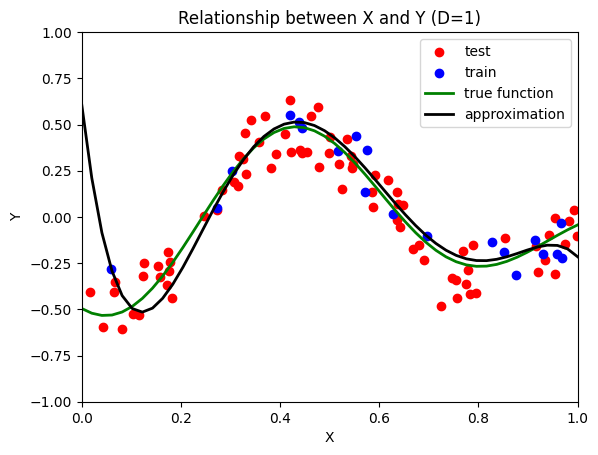

In [ ]:
# Set the polynomial degree
deg = 5

# Fit a polynomial regression model of degree deg to the training data
lin_reg = poly_fit(X_train, Y_train, deg)

# Calculate the Root Mean Squared Error (RMSE) for the training and test sets
RMSE_train = RMSE(poly_apply(lin_reg, deg, X_train), Y_train)
RMSE_test = RMSE(poly_apply(lin_reg, deg, X_test), Y_test)

# Print the RMSE values

print(f"Degree = {deg}, RMSE_train = {RMSE_train:.3f}, RMSE_test = {RMSE_test:.3f}")

# Plot the training and test data points
plt.scatter(X_test, Y_test, color='red', label='test')
plt.scatter(X_train, Y_train, color='blue', label='train')

# Plot the true function curve
data_points = np.linspace(0, 1, 50)[:, None]
plt.plot(data_points, true_function(data_points), color='green', linewidth=2, label='true function')

# Plot the polynomial model's approximation
plt.plot(data_points, poly_apply(lin_reg, deg, data_points), color='black', linewidth=2, label='approximation')

# Set plot labels, limits, and title
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim([0, 1])
plt.ylim([-1, 1])
plt.title('Relationship between X and Y (D=1)')
plt.legend()
plt.show()


## Q5) Evaluating Model Performance Across Polynomial Degrees

We evaluate the performance of polynomial regression models with varying degree.

### TASKS:
1. **Model Fitting and RMSE Calculation**: For each degree from 1 to 8, fit a polynomial regression model to the training data. Then calculate the RMSE for both the training and test sets.

2. **Visualization**: Plot the RMSE values for both the training and test sets against the polynomial degree.

3. **Analysis**: <font color='red'>Discuss the trend in RMSE values as the polynomial degree increases.</font>

From 1 dimension(s) to 2 polynomial feature(s)
Degree = 1, RMSE_train = 0.246, RMSE_test = 0.390
From 1 dimension(s) to 3 polynomial feature(s)
Degree = 2, RMSE_train = 0.166, RMSE_test = 0.273
From 1 dimension(s) to 4 polynomial feature(s)
Degree = 3, RMSE_train = 0.125, RMSE_test = 0.219
From 1 dimension(s) to 5 polynomial feature(s)
Degree = 4, RMSE_train = 0.101, RMSE_test = 0.171
From 1 dimension(s) to 6 polynomial feature(s)
Degree = 5, RMSE_train = 0.072, RMSE_test = 0.158
From 1 dimension(s) to 7 polynomial feature(s)
Degree = 6, RMSE_train = 0.070, RMSE_test = 0.216
From 1 dimension(s) to 8 polynomial feature(s)
Degree = 7, RMSE_train = 0.070, RMSE_test = 0.141
From 1 dimension(s) to 9 polynomial feature(s)
Degree = 8, RMSE_train = 0.069, RMSE_test = 0.540


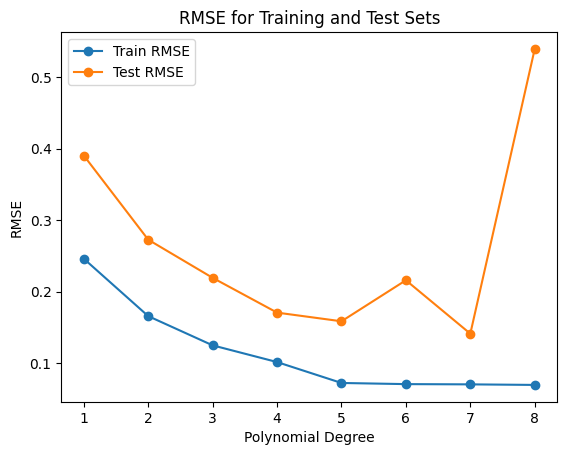

In [ ]:
# Evaluate RMSE for polynomial degrees from 1 to 8
degrees = range(1, 9)  # Define the range of polynomial degrees to evaluate
RMSE_train_list = []  # List to store RMSE for training data
RMSE_test_list = []   # List to store RMSE for test data

# Loop through each degree, fit the model, and calculate RMSE
for deg in degrees:
    # Fit the polynomial regression model on the train with the current degree

    lin_reg = poly_fit(X_train, Y_train, deg)
    RMSE_train = RMSE(poly_apply(lin_reg, deg, X_train), Y_train)
    RMSE_test = RMSE(poly_apply(lin_reg, deg, X_test), Y_test)


    # Calculate the Root Mean Squared Error (RMSE) for the training and test sets

    RMSE_train_list.append(RMSE_train)
    RMSE_test_list.append(RMSE_test)

    print(f"Degree = {deg}, RMSE_train = {RMSE_train:.3f}, RMSE_test = {RMSE_test:.3f}")

# Plot RMSE for training and test sets across different polynomial degrees
plt.plot(degrees, RMSE_train_list, label='Train RMSE', marker='o')
plt.plot(degrees, RMSE_test_list, label='Test RMSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE for Training and Test Sets')
plt.legend()
plt.show()

## Q6) Ridge Regularization in Polynomial Regression

We apply Ridge regularization to our polynomial regression model to prevent overfitting.

### TASK:
1.  **Complete** `poly_fit_ridge(X,Y,deg,alpha)`: This function adding fits a Ridge-regularized regression to $X$ and $Y$. The `alpha` parameter controls the strength of this penalty. A higher `alpha` value leads to more regularization.

2. **Model Fitting and Evaluation**: Fit a Ridge regularized polynomial regression model to the training data using a specified degree and regularization parameter (`alpha = 0.001`). Calculate the RMSE for both the training and test sets to evaluate the model's performance.

3. **Visualization**: Plot the training data points, the true function, and the model's approximation. <font color='red'>Analyze  the effect of different values of alpha for a high degree (8 for example).</font>



Degree = 6, Alpha= 0.001000, RMSE_train = 0.108, RMSE_test = 0.194


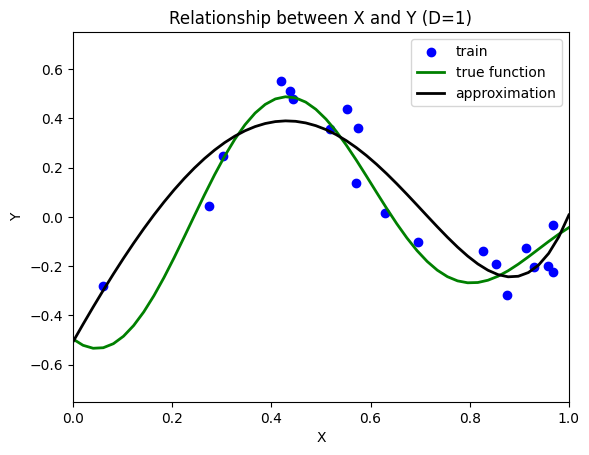

In [ ]:
def poly_fit_ridge(X, Y, deg, alpha=0.1):
    """
    Fits a Ridge regularized polynomial regression model to the data.

    INPUTS:
    X : numpy.ndarray, Input data of shape (N, D)
    Y : numpy.ndarray, Target values of shape (N,)
    degree : int, degree of the polynomial features.
    alpha : float>0, Regularization strength

    RETURNS:
    Ridge, The fitted Ridge regression model.
    """
    # Generate polynomial features up to the specified degree
    X_poly = PolynomialFeatures(degree=deg).fit_transform(X)

    # Initialize and fit the Ridge regression model with the specified regularization strength
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_poly, Y)

    return ridge_reg

# Set the polynomial degree and regularization parameter
deg = 6
alpha = 0.001

# Fit the Ridge regularized polynomial regression model
lin_reg = poly_fit_ridge(X_train, Y_train, deg, alpha)

# Calculate the Root Mean Squared Error (RMSE) for the training and test sets
RMSE_train = RMSE(poly_apply(lin_reg, deg, X_train), Y_train)
RMSE_test = RMSE(poly_apply(lin_reg, deg, X_test), Y_test)

# Print the RMSE values for both training and test sets
print(f"Degree = {deg}, Alpha= {alpha:.6f}, RMSE_train = {RMSE_train:.3f}, RMSE_test = {RMSE_test:.3f}")

# Plot the training data points
plt.scatter(X_train, Y_train, color='blue', label='train')

# Plot the true and predicted function curve
line_points = np.linspace(0, 1, 50)[:, None]
plt.plot(line_points, true_function(line_points), color='green', linewidth=2, label='true function')
plt.plot(line_points, poly_apply(lin_reg, deg, line_points), color='black', linewidth=2, label='approximation')

# Set plot labels, limits, and title
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim([0, 1])
plt.ylim([-0.75, 0.75])
plt.title('Relationship between X and Y (D=1)')
plt.legend()
plt.show()

## Q7) Hyperparameter Tuning: Degree and Alpha in Ridge Regularization

We perform hyperparameter tuning to find the optimal polynomial degree and regularization strength for our Ridge regularized polynomial regression model.

### TASKS:
1. **Hyperparameter Grid Search**: For each combination of degree and alpha from 1 to 10 and alpha values ranging from `1e-4` to `1e-6`, fit a Ridge regularized polynomial regression model to the training data and calculate the RMSE for both the training and test sets.

2. **Identifying Optimal Parameters**: Identify the degree and alpha that yield the lowest RMSE on the training and test set.

3. **Heatmap Visualization**: Create heatmaps of the RMSE values for both the training and test sets across different combinations of polynomial degrees and alpha values.

4. **Analysis** <font color='red'> Are the best parameters the same for train and test? Compare the value of the error for both sets of parameters. If not, why? </font>


We can't pick the best parameterization by directly looking at the test values: we typically do not have access to them at training time. We need a validation set.


In [ ]:
K = 10 #granularity  of search space

# Define the range of polynomial degrees and alpha values for Ridge regularization
degrees = range(1, K+1)
alphas  =  np.logspace(-4, -6, num=K)

# Initialize arrays to store RMSE values for training and test sets
RMSE_train_array = np.zeros((K,K))
RMSE_test_array = np.zeros((K,K))

# Loop through each degree and alpha value to fit the model and calculate RMSE
for d, deg in enumerate(degrees):
    for a, alp in enumerate(alphas):
        # Fit the Ridge regularized polynomial regression model
        lin_reg = poly_fit_ridge(X_train, Y_train, deg, alp)
        RMSE_train = RMSE(poly_apply(lin_reg, deg, X_train), Y_train)
        RMSE_test = RMSE(poly_apply(lin_reg, deg, X_test), Y_test)

        # Store the RMSE values
        RMSE_train_array[d, a] = RMSE_train
        RMSE_test_array[d, a] = RMSE_test

In [ ]:
# Find the configuration with the minimum RMSE for the training set
min_index_train = np.unravel_index(np.argmin(RMSE_train_array), RMSE_train_array.shape)
best_degree_train = degrees[min_index_train[0]]
best_alpha_train = alphas[min_index_train[1]]
best_RMSE_train = RMSE_train_array[min_index_train]

# Print the best configuration for the training set
print(f"Best RMSE_TRAIN = {best_RMSE_train:.3f} reached for deg = {best_degree_train} and alpha = {best_alpha_train:.7f}")

# Find the configuration with the minimum RMSE for the test set
min_index_test = np.unravel_index(np.argmin(RMSE_test_array), RMSE_test_array.shape)
best_degree_test = degrees[min_index_test[0]]
best_alpha_test = alphas[min_index_test[1]]
best_RMSE_test = RMSE_test_array[min_index_test]

# Print the best configuration for the test set
print(f"Best RMSE_TEST = {best_RMSE_test:.3f} reached for deg = {best_degree_test} and alpha = {best_alpha_test:.7f}")

Best RMSE_TRAIN = 0.074 reached for deg = 10 and alpha = 0.0000010
Best RMSE_TEST = 0.133 reached for deg = 10 and alpha = 0.0000010


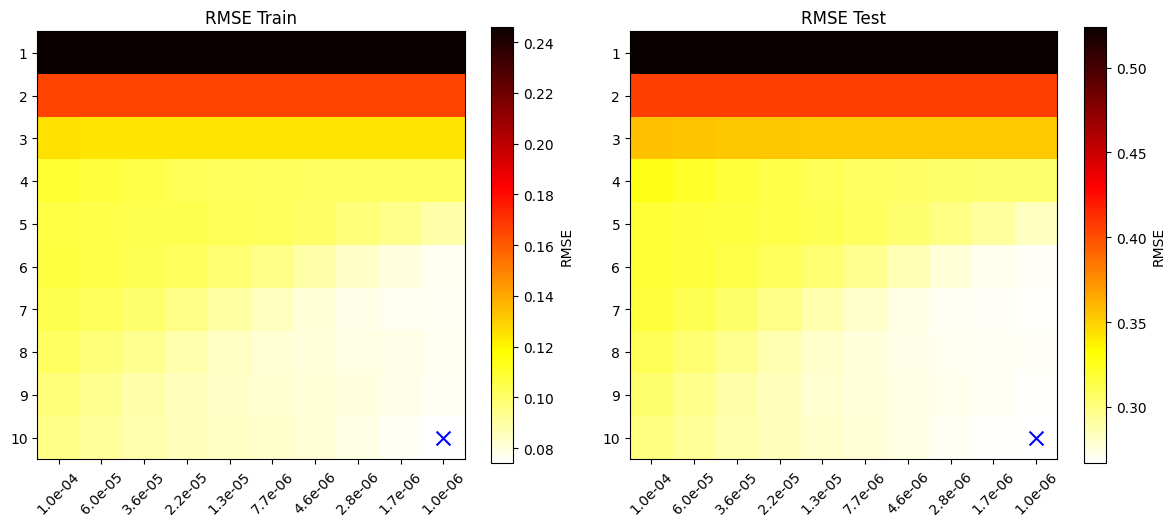

In [ ]:
plt.figure(figsize=(12, 5))  # Set the figure size for the subplots

# Plot RMSE for the training set
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.imshow(RMSE_train_array, cmap='hot_r', origin='upper')  # Use a heatmap with the negative RMSE (for visualization)
plt.title("RMSE Train")  # Title for the training set subplot
plt.xticks(ticks=range(10), labels=[f'{y:.1e}' for y in alphas], rotation=45)  # Set x-axis ticks to show alpha values
plt.yticks(ticks=range(10), labels=degrees)  # Set y-axis ticks to show polynomial degrees
plt.colorbar(label='RMSE')  # Add a color bar for the heatmap
plt.scatter(min_index_train[1], min_index_train[0], color='blue', marker='x', s=100) #plot the best value

# Plot RMSE for the test set
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.imshow(RMSE_test_array + RMSE_test_array.min(), cmap='hot_r', origin='upper')  # Use a heatmap with the negative RMSE (for visualization)
plt.title("RMSE Test")  # Title for the test set subplot
plt.xticks(ticks=range(10), labels=[f'{y:.1e}' for y in alphas], rotation=45)  # Set x-axis ticks to show alpha values
plt.yticks(ticks=range(10), labels=degrees)  # Set y-axis ticks to show polynomial degrees
plt.colorbar(label='RMSE')  # Add a color bar for the heatmap
plt.scatter(min_index_test[1], min_index_test[0], color='blue', marker='x', s=100)

plt.tight_layout()
plt.show()

## Q8) Higher Dimensional Data and Validation Set

We now generate 2D data and introduce a validation set.

### TASKS:
1. **Data Generation**: Generate synthetic data with 2 dimensions (`D=2`) and a large number of samples (`N=10,000`) to visualize the relationship between the input variables `X` and the target variable `Y` with the function `view_2D`.

2. **Data Splitting**:  Generate a smaller dataset (`N=1,000`) for model training and evaluation  and split into three sets:
     - `Training Set`: To train the model.
     - `Validation Set`: To tune hyperparameters and avoid overfitting.
     - `Test Set`: To evaluate the final model's performance.

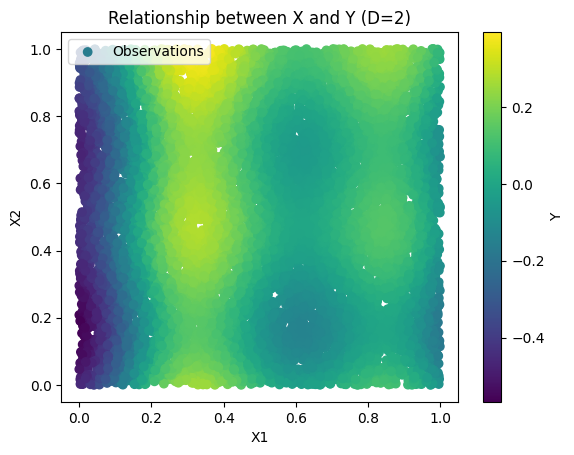

In [ ]:
# Function to visualize 2D data
def view_2D(X, Y):
    """
    Visualizes the relationship between 2D input data and the target variable.

    Parameters:
    X : numpy.ndarray, Input data of shape (N, 2)
    Y : numpy.ndarray, Target values of shape (N,).
    """
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', label='Observations')
    plt.colorbar(label='Y')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Relationship between X and Y (D=2)')
    plt.legend()
    plt.show()

# Generate 2D synthetic data with 10,000 samples and no noise
X, Y = generate_data(D=2, N=10000, noise_level=0)
view_2D(X, Y)  # Visualize the data

In [ ]:
# Generate 5-D synthetic data in with 1,000 samples and no noise
X, Y = generate_data(D=5, N=1000, noise_level=0)

# Split the data into train-validation (20%) and test (80%) sets
X_trainval, X_test, Y_trainval, Y_test = train_test_split(X, Y, test_size=0.8, train_size=0.2)

# Further split the train-validation set into training (80%) and validation sets (20%)
X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size=0.2)

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (160, 5)
X_val shape: (40, 5)
X_test shape: (800, 5)


## Q9) Model Selection Using Validation Set

In this final step, we perform hyperparameter tuning by on the validation set. This ensures that the test set remains untouched until the final evaluation, preventing any "cheating."

### TASKS:
1. **Model Fitting and RMSE Calculation**: For each combination of degree and alpha, fit a Ridge regularized polynomial regression model on the training set and calculate the RMSE for the training, validation, and test sets.
2. **Model Selection**: Select the model with the lowest RMSE on the validation set and evaluate its performance on the test set. <font color='red'>How does it compare to the best model tuned on the train set and test set?</font>
3. **Results Visualization**: Visualize the RMSE heatmaps for the training, validation, and test sets. Highlight the best hyperparameters for each set. <font color='red'> Are the best parameters for the validations also the best for the test?</font>


In [ ]:
K = 10 #granularity  of search space

# Define the range of polynomial degrees and alpha values for Ridge regularization
degrees = range(1, K+1)
alphas  =  np.logspace(-4, -6, num=K)

# Initialize arrays to store RMSE values for training and test sets
RMSE_train_array = np.zeros((K,K))
RMSE_test_array = np.zeros((K,K))
RMSE_val_array = np.zeros((K,K))

# Loop through each degree and alpha value to fit the model and calculate RMSE
for d, deg in enumerate(degrees):
    for a, alp in enumerate(alphas):
        # Fit the Ridge regularized polynomial regression model
        lin_reg = poly_fit_ridge(X_train, Y_train, deg, alp)
        RMSE_train = RMSE(poly_apply(lin_reg, deg, X_train), Y_train)
        RMSE_test = RMSE(poly_apply(lin_reg, deg, X_test), Y_test)
        RMSE_val = RMSE(poly_apply(lin_reg, deg, X_val), Y_val)

        # Store the RMSE values
        RMSE_train_array[d, a] = RMSE_train
        RMSE_test_array[d, a] = RMSE_test
        RMSE_val_array[d, a] = RMSE_val

In [ ]:
# Find the configuration with the minimum RMSE for the training set
min_index_train = np.unravel_index(np.argmin(RMSE_train_array), RMSE_train_array.shape)
best_degree_train = degrees[min_index_train[0]]
best_alpha_train = alphas[min_index_train[1]]
best_RMSE_train = RMSE_train_array[min_index_train]

# Print the best configuration for the training set
print(f"Best RMSE_TRAIN = {best_RMSE_train:.3f} reached for deg = {best_degree_train} and alpha = {best_alpha_train:.7f}")

# Find the configuration with the minimum RMSE for the test set
min_index_test = np.unravel_index(np.argmin(RMSE_test_array), RMSE_test_array.shape)
best_degree_test = degrees[min_index_test[0]]
best_alpha_test = alphas[min_index_test[1]]
best_RMSE_test = RMSE_test_array[min_index_test]

# Print the best configuration for the test set
print(f"Best RMSE_TEST = {best_RMSE_test:.3f} reached for deg = {best_degree_test} and alpha = {best_alpha_test:.7f}")


# Find the configuration with the minimum RMSE for the val set
min_index_val = np.unravel_index(np.argmin(RMSE_val_array), RMSE_val_array.shape)
best_degree_val = degrees[min_index_val[0]]
best_alpha_val = alphas[min_index_val[1]]
best_RMSE_val = RMSE_val_array[min_index_val]

# Print the best configuration for the val set
print(f"Best RMSE_VAL = {best_RMSE_val:.3f} reached for deg = {best_degree_val} and alpha = {best_alpha_val:.7f}")

Best RMSE_TRAIN = 0.000 reached for deg = 10 and alpha = 0.0000010
Best RMSE_TEST = 0.655 reached for deg = 3 and alpha = 0.0001000
Best RMSE_VAL = 0.650 reached for deg = 4 and alpha = 0.0001000


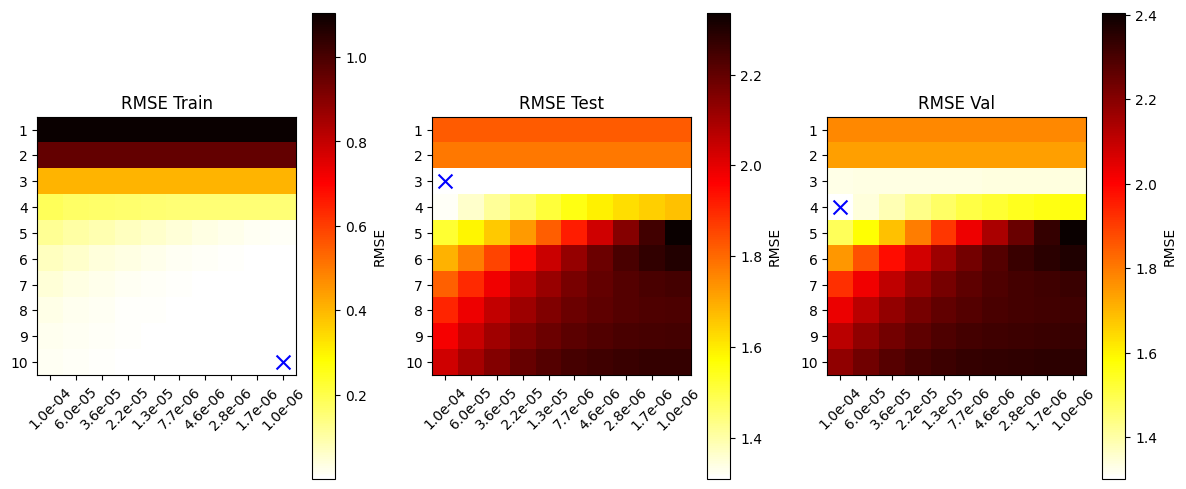

In [ ]:
plt.figure(figsize=(12, 5))  # Set the figure size for the subplots

# Plot RMSE for the training set
plt.subplot(1, 3, 1)  # 1 row, 3 columns, 1st subplot
plt.imshow(RMSE_train_array, cmap='hot_r', origin='upper')  # Use a heatmap with the negative RMSE (for visualization)
plt.title("RMSE Train")  # Title for the training set subplot
plt.xticks(ticks=range(10), labels=[f'{y:.1e}' for y in alphas], rotation=45)  # Set x-axis ticks to show alpha values
plt.yticks(ticks=range(10), labels=degrees)  # Set y-axis ticks to show polynomial degrees
plt.colorbar(label='RMSE')  # Add a color bar for the heatmap
plt.scatter(min_index_train[1], min_index_train[0], color='blue', marker='x', s=100) #plot the best value

# Plot RMSE for the test set
plt.subplot(1, 3, 2)  # 1 row, 3 columns, 2nd subplot
plt.imshow(RMSE_test_array + RMSE_test_array.min(), cmap='hot_r', origin='upper')  # Use a heatmap with the negative RMSE (for visualization)
plt.title("RMSE Test")  # Title for the test set subplot
plt.xticks(ticks=range(10), labels=[f'{y:.1e}' for y in alphas], rotation=45)  # Set x-axis ticks to show alpha values
plt.yticks(ticks=range(10), labels=degrees)  # Set y-axis ticks to show polynomial degrees
plt.colorbar(label='RMSE')  # Add a color bar for the heatmap
plt.scatter(min_index_test[1], min_index_test[0], color='blue', marker='x', s=100)

# Plot RMSE for the val test
plt.subplot(1, 3, 3)  # 1 row, 3 columns, 3rd subplot
plt.imshow(RMSE_val_array + RMSE_val_array.min(), cmap='hot_r', origin='upper')  # Use a heatmap with the negative RMSE (for visualization)
plt.title("RMSE Val")  # Title for the test set subplot
plt.xticks(ticks=range(10), labels=[f'{y:.1e}' for y in alphas], rotation=45)  # Set x-axis ticks to show alpha values
plt.yticks(ticks=range(10), labels=degrees)  # Set y-axis ticks to show polynomial degrees
plt.colorbar(label='RMSE')  # Add a color bar for the heatmap
plt.scatter(min_index_val[1], min_index_val[0], color='blue', marker='x', s=100)

plt.tight_layout()
plt.show()